# TP – Classification de Pneumonie sur Radiographies Thoraciques

**Objectif :** Construire un réseau de neurones convolutionnel (CNN) pour classifier les radiographies thoraciques en deux catégories : **Normal** ou **Pneumonie**.

**Description du dataset (Labeled Chest X-Ray Images) :**  
Ce dataset contient des radiographies thoraciques pédiatriques organisées en deux classes. Les images sont réparties en trois dossiers `train/`, `val/`, et `test/`, chacun contenant deux sous-dossiers :

| Dossier | Description |
|---------|-------------|
| `NORMAL/` | Radiographies de poumons sains |
| `PNEUMONIA/` | Radiographies de poumons atteints de pneumonie |

| Champ  | Valeur |
|--------|--------|
| label | 0 = Normal, 1 = Pneumonia |
| Taille | 64×64 pixels (redimensionné) |
| Canaux | RGB (3 canaux) |

**Source :** [Kaggle – Labeled Chest X-Ray Images](https://www.kaggle.com/datasets/tolgadincer/labeled-chest-xray-images/data)

### Type de problème

Classification binaire :
- **Input :** image radiographique (64×64×3)
- **Output :** diagnostic — 0 (Normal) ou 1 (Pneumonia)

## 1. Importation des bibliothèques

In [58]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras import Input, layers
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## 2. Chargement et préparation du dataset

Le dataset est organisé avec des dossiers `train/`, `val/`, et `test/` déjà fournis par Kaggle.  
Chaque dossier contient deux sous-dossiers : `NORMAL/` et `PNEUMONIA/`.

Les images sont :
- Lues en couleur (RGB)
- Redimensionnées en **64×64** pixels
- Normalisées entre **0 et 1**
- Étiquetées : **0 = Normal**, **1 = Pneumonia**

> **Note :** Le dataset Kaggle dispose déjà d'un split train/val/test, nous l'utilisons directement.

In [59]:
IMG_SIZE = 128  # Augmenté de 64 → 128 pour plus de détail
DATA_PATH = "chest_xray"

def load_split(split_name):
    images, labels = [], []
    label_map = {'NORMAL': 0, 'PNEUMONIA': 1}
    split_path = os.path.join(DATA_PATH, split_name)
    for class_name, label in label_map.items():
        class_path = os.path.join(split_path, class_name)
        if not os.path.exists(class_path):
            print(f"[WARN] Dossier introuvable : {class_path}")
            continue
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                img = cv2.imread(img_path)
                if img is None:
                    continue
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                images.append(img)
                labels.append(label)
            except Exception:
                pass

    if len(images) == 0:
        return np.empty((0, IMG_SIZE, IMG_SIZE, 3), dtype=np.float32), np.empty((0,), dtype=np.int32)

    X = np.array(images, dtype=np.float32) / 255.0
    y = np.array(labels, dtype=np.int32)
    return X, y

X_train, y_train = load_split('train')
X_val,   y_val   = load_split('val')
X_test,  y_test  = load_split('test')

if len(X_val) == 0:
    print("[INFO] val/ vide — split 10% depuis train")
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.1, random_state=42, stratify=y_train)

print("X_train:", X_train.shape, " | Classes:", np.bincount(y_train))
print("X_val  :", X_val.shape,   " | Classes:", np.bincount(y_val))
print("X_test :", X_test.shape,  " | Classes:", np.bincount(y_test))


[WARN] Dossier introuvable : chest_xray\val\NORMAL
[WARN] Dossier introuvable : chest_xray\val\PNEUMONIA
[INFO] val/ vide — split 10% depuis train
X_train: (4708, 128, 128, 3)  | Classes: [1214 3494]
X_val  : (524, 128, 128, 3)  | Classes: [135 389]
X_test : (624, 128, 128, 3)  | Classes: [234 390]


## 3. Exploration des données

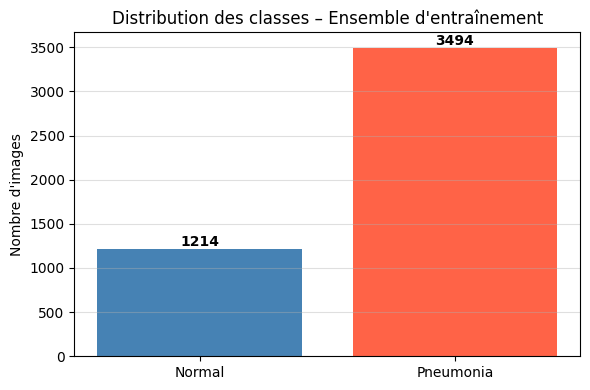

In [ ]:
# Distribution des classes
label_names = ['Normal', 'Pneumonia']
counts = np.bincount(y_train)

plt.figure(figsize=(6, 4))
plt.bar(label_names, counts, color=['steelblue', 'tomato'])
plt.title('Distribution des classes _ Ensemble d\'entraînement')
plt.ylabel('Nombre d\'images')
plt.grid(axis='y', alpha=0.4)
for i, c in enumerate(counts):
    plt.text(i, c + 30, str(c), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

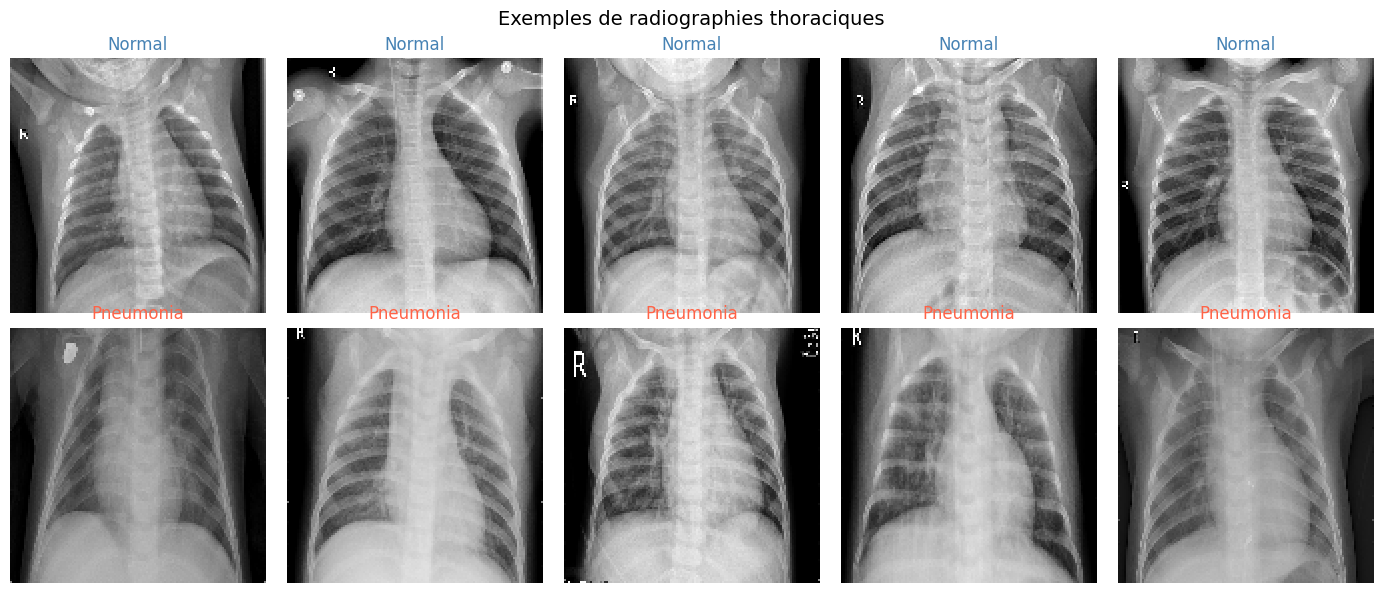

In [61]:
# Affichage d'exemples d'images (Normal vs Pneumonia)
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Exemples de radiographies thoraciques', fontsize=14)

for col, label in enumerate([0, 1]):
    idxs = np.where(y_train == label)[0][:5]
    for row, idx in enumerate(idxs):
        ax = axes[col][row]
        ax.imshow(X_train[idx], cmap='gray')
        ax.set_title(label_names[label], color='steelblue' if label == 0 else 'tomato')
        ax.axis('off')

plt.tight_layout()
plt.show()

In [62]:
# Informations sur les données
print("Shape d'une image :", X_train[0].shape)
print("Min / Max :", X_train[0].min(), "/", X_train[0].max())
print("Dtype :", X_train.dtype)

Shape d'une image : (128, 128, 3)
Min / Max : 0.0 / 0.78039217
Dtype : float32


## 4. Gestion du déséquilibre de classes

Le dataset Chest X-Ray est **déséquilibré** : il y a beaucoup plus d'images Pneumonia que Normal dans l'ensemble d'entraînement.  
Pour corriger cela, on calcule des **class weights** qui pénalisent davantage les erreurs sur la classe minoritaire.

In [63]:
from sklearn.utils.class_weight import compute_class_weight

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = {0: class_weights_array[0], 1: class_weights_array[1]}
print("Class weights :", class_weights)

Class weights : {0: np.float64(1.9390444810543657), 1: np.float64(0.6737263880938752)}


## 4b. Data Augmentation

L'augmentation de données génère des variantes des images d'entraînement (rotations, flips, zoom) pour réduire le surapprentissage et améliorer la généralisation du modèle.
- `horizontal_flip` : symétrie réaliste pour des radiographies thoraciques
- `rotation_range` : légères rotations (≤10°)
- `zoom_range` / `width_shift_range` : variabilité de positionnement du patient


In [64]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)
datagen.fit(X_train)
print("ImageDataGenerator configuré.")


ImageDataGenerator configuré.


## 5. Construction du CNN (Functional API)

L'architecture reprend la même structure que le modèle de prédiction de genre :
trois blocs **Conv2D + MaxPooling + Dropout** pour l'extraction de features,
suivis de couches **Dense** pour la classification binaire.

- **Conv2D** : extraction de caractéristiques visuelles (contours, textures)
- **MaxPooling2D** : réduction spatiale
- **Dropout** : régularisation pour éviter le surapprentissage
- **Sortie sigmoid** : probabilité d'appartenir à la classe Pneumonia (1)

In [65]:
inputs = Input(shape=(128, 128, 3), name='input_xray')

# Bloc 1
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.25)(x)

# Bloc 2
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.25)(x)

# Bloc 3
x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.3)(x)

# Bloc 4
x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.GlobalAveragePooling2D()(x)  # Plus robuste que Flatten

x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)

output = layers.Dense(1, activation='sigmoid', name='pneumonia_output')(x)

model = Model(inputs=inputs, outputs=output)
model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_xray (InputLayer)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 682,913 (2.61 MB)

 Trainable params: 681,953 (2.60 MB)

 Non-trainable params: 960 (3.75 KB)

## 6. Compilation du modèle

- **Optimiseur :** Adam
- **Fonction de perte :** Binary Crossentropy (adaptée à la classification binaire)
- **Métriques :** Accuracy + AUC (l'AUC est utile sur des datasets déséquilibrés)

In [66]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Recall(name='recall'),
             tf.keras.metrics.Precision(name='precision')]
)


## 7. Entraînement

Le modèle est entraîné pendant **20 epochs** (max) avec un batch size de 32.  
- **EarlyStopping** : arrêt anticipé si la val_loss ne s'améliore pas (patience=5)
- **ModelCheckpoint** : sauvegarde du meilleur modèle
- **class_weight** : compensation du déséquilibre de classes

In [ ]:
callbacks = [
    EarlyStopping(
        monitor='val_auc', mode='max',
        patience=7, restore_best_weights=True, verbose=1
    ),
    ModelCheckpoint(
        filepath='best_xray_model.keras',
        monitor='val_auc', mode='max',
        save_best_only=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3,
        min_lr=1e-6, verbose=1
    )
]

BATCH_SIZE = 32
steps_per_epoch = len(X_train) // BATCH_SIZE

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    steps_per_epoch=steps_per_epoch,
    epochs=30,
    validation_data=(X_val, y_val),
    class_weight=class_weights,
    callbacks=callbacks
)


Epoch 1/30
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8323 - auc: 0.9085 - loss: 0.3653 - precision: 0.9500 - recall: 0.8186
Epoch 1: val_auc improved from None to 0.50000, saving model to best_xray_model.keras

Epoch 1: finished saving model to best_xray_model.keras
147/147 ━━━━━━━━━━━━━━━━━━━━ 213s 1s/step - accuracy: 0.8663 - auc: 0.9423 - loss: 0.3059 - precision: 0.9672 - recall: 0.8488 - val_accuracy: 0.7424 - val_auc: 0.5000 - val_loss: 3.8125 - val_precision: 0.7424 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/30
  1/147 ━━━━━━━━━━━━━━━━━━━━ 3:16 1s/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.1309 - precision: 1.0000 - recall: 1.0000

c:\Users\4B\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_auc did not improve from 0.50000
147/147 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.1309 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.7424 - val_auc: 0.5000 - val_loss: 3.9225 - val_precision: 0.7424 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/30
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8896 - auc: 0.9686 - loss: 0.2291 - precision: 0.9825 - recall: 0.8657
Epoch 3: val_auc did not improve from 0.50000
147/147 ━━━━━━━━━━━━━━━━━━━━ 210s 1s/step - accuracy: 0.8967 - auc: 0.9684 - loss: 0.2274 - precision: 0.9776 - recall: 0.8810 - val_accuracy: 0.7424 - val_auc: 0.5000 - val_loss: 2.9720 - val_precision: 0.7424 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/30
  1/147 ━━━━━━━━━━━━━━━━━━━━ 3:28 1s/step - accuracy: 0.9375 - auc: 0.9662 - loss: 0.2476 - precision: 1.0000 - recall: 0.9130
Epoch 4: val_auc did not improve from 0.50000
147/147 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.9375 - auc: 0.9662 

In [68]:
print(X_train.shape)
print(y_train.shape)

(4708, 128, 128, 3)
(4708,)


## 8. Évaluation sur le jeu de test

In [69]:
results = model.evaluate(X_test, y_test, verbose=1)
print("\n--- Résultats sur le jeu de test ---")
for name, val in zip(model.metrics_names, results):
    print(f"{name}: {val:.4f}")

# Sauvegarde du modèle final
model.save('best_xray_model.keras')
print("\nModèle sauvegardé : best_xray_model.keras")

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 269ms/step - accuracy: 0.9199 - auc: 0.9784 - loss: 0.2290 - precision: 0.8935 - recall: 0.9897

--- Résultats sur le jeu de test ---
loss: 0.2290
compile_metrics: 0.9199

Modèle sauvegardé : best_xray_model.keras


## 9. Courbes Loss / Accuracy

Visualisation des courbes d'entraînement et de validation pour diagnostiquer le surapprentissage.

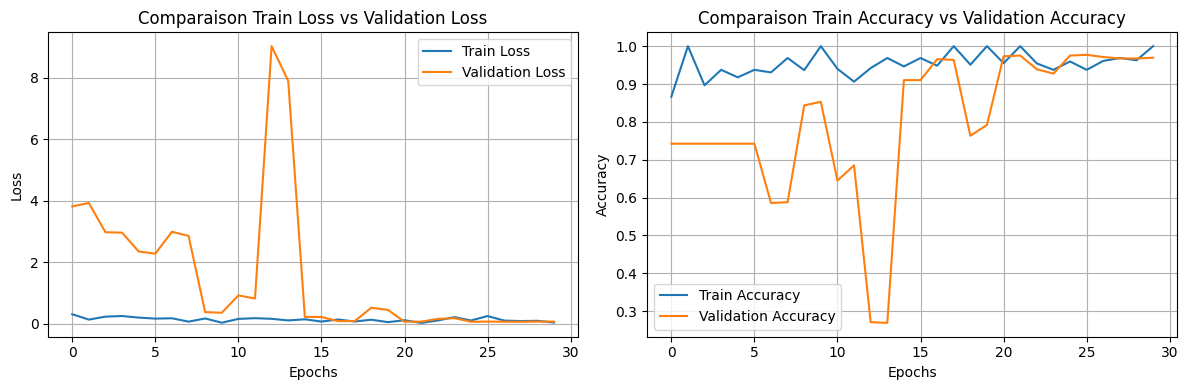

In [70]:
# Loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Comparaison Train Loss vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Comparaison Train Accuracy vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

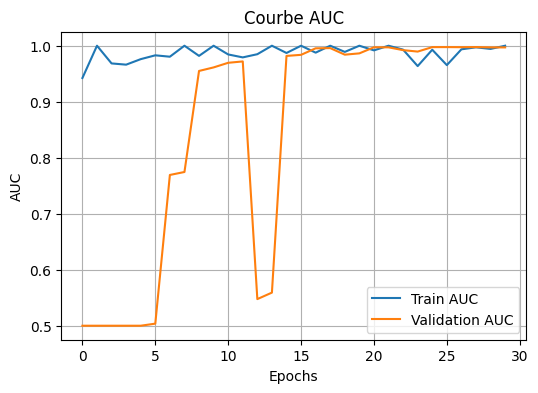

In [71]:
# Courbe AUC
plt.figure(figsize=(6, 4))
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Validation AUC')
plt.title('Courbe AUC')
plt.xlabel('Epochs')
plt.ylabel('AUC')
plt.legend()
plt.grid()
plt.show()

In [72]:
y_pred = model.predict(X_test)

y_pred_classes = (y_pred > 0.5).astype(int)

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 269ms/step


In [73]:
from sklearn.metrics import accuracy_score

# y_pred_classes = model.predict(X_test).flatten() > 0.5
accuracy = accuracy_score(y_test, y_pred_classes)
print("Accuracy:", accuracy)

Accuracy: 0.9198717948717948


## 10. Prédictions

In [74]:
predictions = model.predict(X_test)
print("Exemple de probabilité brute (1ère image) :", predictions[0])
print("Prédiction : ", 'Pneumonia' if predictions[0] > 0.5 else 'Normal')
print("Vraie classe :", label_names[y_test[0]])

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 277ms/step
Exemple de probabilité brute (1ère image) : [0.18810154]
Prédiction :  Normal
Vraie classe : Normal


## 11. Matrice de confusion

La matrice de confusion permet d'analyser les erreurs de classification :
- **Vrais Positifs / Négatifs** : prédictions correctes
- **Faux Positifs** : Normal prédit comme Pneumonia (sur-diagnostic)
- **Faux Négatifs** : Pneumonia prédit comme Normal (sous-diagnostic, plus dangereux cliniquement)

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 276ms/step
Seuil optimal (max F1) : 0.81


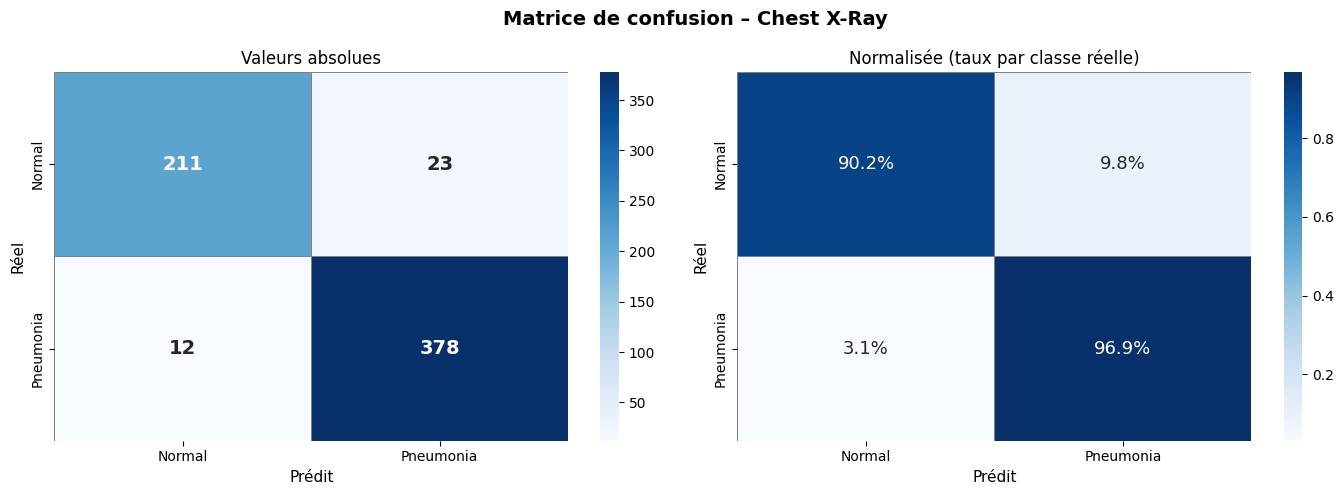


  Seuil utilisé           : 0.81
  Vrais Positifs (TP)     : 378
  Vrais Négatifs (TN)     : 211
  Faux Positifs  (FP)     : 23  ← sur-diagnostic
  Faux Négatifs  (FN)     : 12  ← DANGEREUX (manqués)
  Sensibilité (Recall)    : 0.9692
  Spécificité             : 0.9017

Rapport de classification :
              precision    recall  f1-score   support

      Normal       0.95      0.90      0.92       234
   Pneumonia       0.94      0.97      0.96       390

    accuracy                           0.94       624
   macro avg       0.94      0.94      0.94       624
weighted avg       0.94      0.94      0.94       624



In [75]:
# ── Optimisation du seuil de décision ──────────────────────────────────────
from sklearn.metrics import f1_score

y_proba = model.predict(X_test).flatten()

# Trouver le seuil qui maximise le F1-score
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = [f1_score(y_test, (y_proba >= t).astype(int)) for t in thresholds]
best_thresh = thresholds[np.argmax(f1_scores)]
print(f"Seuil optimal (max F1) : {best_thresh:.2f}")

y_pred_classes = (y_proba >= best_thresh).astype(int)

# ── Matrice de confusion améliorée ──────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_classes)
cm_norm = confusion_matrix(y_test, y_pred_classes, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Matrice de confusion – Chest X-Ray', fontsize=14, fontweight='bold')

# Gauche : valeurs absolues
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'],
            linewidths=0.5, linecolor='gray',
            annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_title('Valeurs absolues', fontsize=12)
axes[0].set_xlabel('Prédit', fontsize=11)
axes[0].set_ylabel('Réel', fontsize=11)

# Droite : normalisée (taux de bonne classification par classe)
sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='Blues', ax=axes[1],
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'],
            linewidths=0.5, linecolor='gray',
            annot_kws={'size': 13})
axes[1].set_title('Normalisée (taux par classe réelle)', fontsize=12)
axes[1].set_xlabel('Prédit', fontsize=11)
axes[1].set_ylabel('Réel', fontsize=11)

plt.tight_layout()
plt.show()

# ── Statistiques détaillées ─────────────────────────────────────────────────
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)   # Recall pour Pneumonia
specificity = tn / (tn + fp)   # Recall pour Normal
print(f"\n{'='*45}")
print(f"  Seuil utilisé           : {best_thresh:.2f}")
print(f"  Vrais Positifs (TP)     : {tp}")
print(f"  Vrais Négatifs (TN)     : {tn}")
print(f"  Faux Positifs  (FP)     : {fp}  ← sur-diagnostic")
print(f"  Faux Négatifs  (FN)     : {fn}  ← DANGEREUX (manqués)")
print(f"  Sensibilité (Recall)    : {sensitivity:.4f}")
print(f"  Spécificité             : {specificity:.4f}")
print(f"{'='*45}")
print("\nRapport de classification :")
print(classification_report(y_test, y_pred_classes, target_names=['Normal', 'Pneumonia']))


## 12. Visualisation des erreurs

Affichage de quelques images mal classifiées pour comprendre les limites du modèle.

Nombre d'erreurs : 35 / 624


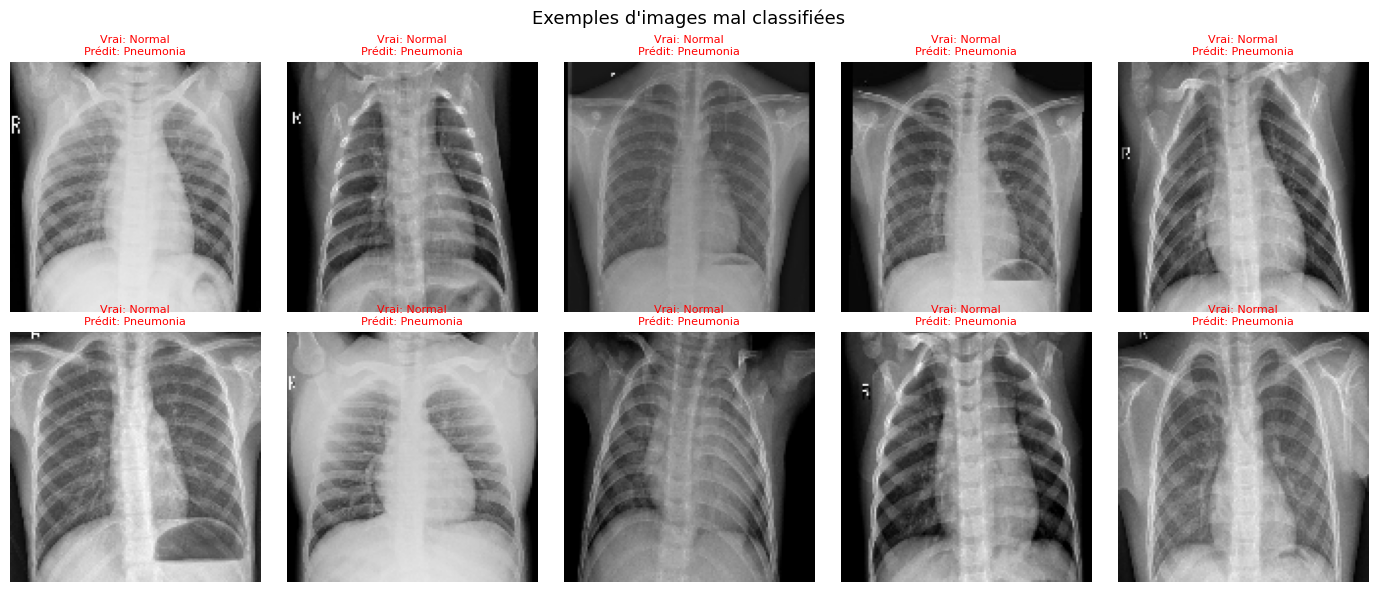

In [76]:
errors = np.where(y_pred_classes != y_test)[0]
print(f"Nombre d'erreurs : {len(errors)} / {len(y_test)}")

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Exemples d\'images mal classifiées', fontsize=13)

for i, idx in enumerate(errors[:10]):
    ax = axes[i // 5][i % 5]
    ax.imshow(X_test[idx])
    ax.set_title(
        f"Vrai: {label_names[y_test[idx]]}\nPrédit: {label_names[y_pred_classes[idx]]}",
        color='red', fontsize=8
    )
    ax.axis('off')

plt.tight_layout()
plt.show()

## Conclusion

**Points clés adaptés pour ce dataset :**

- Le dataset Kaggle fournit directement des splits train/val/test, donc aucun `train_test_split` manuel n'est nécessaire.
- Le dataset est **déséquilibré** (plus de cas Pneumonia que Normal dans le train) : les **class weights** compensent ce déséquilibre sans modifier les données.
- L'**AUC** a été ajoutée comme métrique complémentaire à l'accuracy, car elle est plus robuste sur des données déséquilibrées.
- Les **Faux Négatifs** (Pneumonia classée Normal) sont cliniquement les plus dangereux et méritent une attention particulière dans le rapport de classification.

**Pistes d'amélioration :**
- Data augmentation (rotation, flip horizontal) pour augmenter la robustesse
- Transfer Learning avec un modèle pré-entraîné (VGG16, ResNet50) pour de meilleures performances
- Ajuster le seuil de décision (par défaut 0.5) selon les contraintes cliniques